<a href="https://colab.research.google.com/github/BrayFlo/Mineria-Datos/blob/main/Clusters3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#16 de Abril del 2026
#Bryan Hernández Flores
#Clustering (Allgoritmos de Agrupamiento)

In [2]:
import numpy as np #Biblioteca para calculos numericos
import matplotlib.pyplot as plt #Para graficar
from sklearn.cluster import KMeans # Implementacion de K'Means en sklearn
import pandas as pd

In [3]:
data = {
    "Horas_estudio": [1,2,1.5,8,9, 8.5,3,3.5,4],
    "Calificaciones": [2,3,2.5,9,10,9.5,5,5.5,6]
}

df = pd.DataFrame(data)
df

,Horas_estudio,Calificaciones
0,1.0,2.0
1,2.0,3.0
2,1.5,2.5
3,8.0,9.0
4,9.0,10.0
5,8.5,9.5
6,3.0,5.0
7,3.5,5.5
8,4.0,6.0


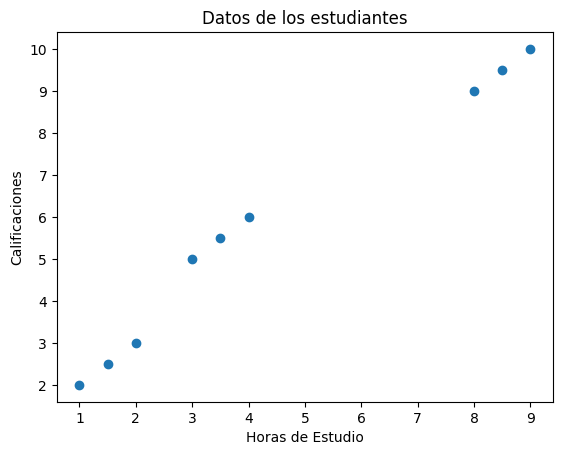

In [4]:
#Visualizacion de los datos originales
plt.scatter(df["Horas_estudio"], df["Calificaciones"])
plt.xlabel("Horas de Estudio")
plt.ylabel("Calificaciones")
plt.title("Datos de los estudiantes")
plt.show()

In [5]:
# --- PASO NUEVO: MÉTODO DEL CODO ---
from sklearn.cluster import KMeans # Ensure KMeans is imported

inercia = []
ks = range(1, 7) # Probamos de 1 a 6 clusters

for k in ks:
    km = KMeans(n_clusters=k, random_state=0)
    km.fit(df)
    inercia.append(km.inertia_)

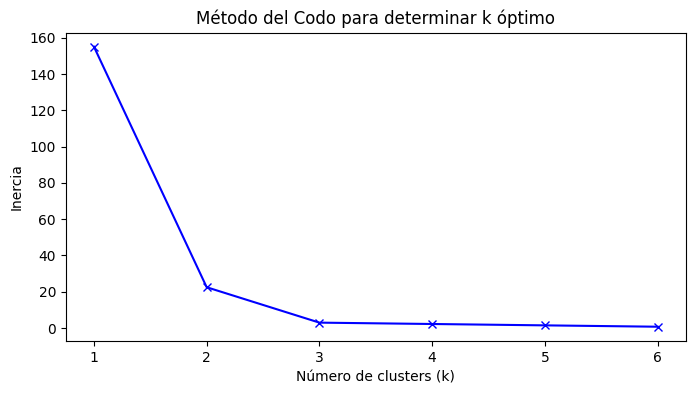

In [6]:
# Graficar el codo
plt.figure(figsize=(8,4))
plt.plot(ks, inercia, 'bx-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo para determinar k óptimo')
plt.show()
# ----------------------------------

In [7]:
# Basado en la gráfica, elegimos el 'codo' (que parece ser 2 o 3)
k_optimo = 3
kmeans = KMeans(n_clusters=k_optimo, random_state=0)
kmeans.fit(df)

KMeans(n_clusters=3, random_state=0)

In [8]:
# Mostrar resultados
centroides = kmeans.cluster_centers_
df['Cluster'] = kmeans.labels_

In [9]:
df['Cluster'] = kmeans.labels_
df

,Horas_estudio,Calificaciones,Cluster
0,1.0,2.0,2
1,2.0,3.0,2
2,1.5,2.5,2
3,8.0,9.0,0
4,9.0,10.0,0
5,8.5,9.5,0
6,3.0,5.0,1
7,3.5,5.5,1
8,4.0,6.0,1


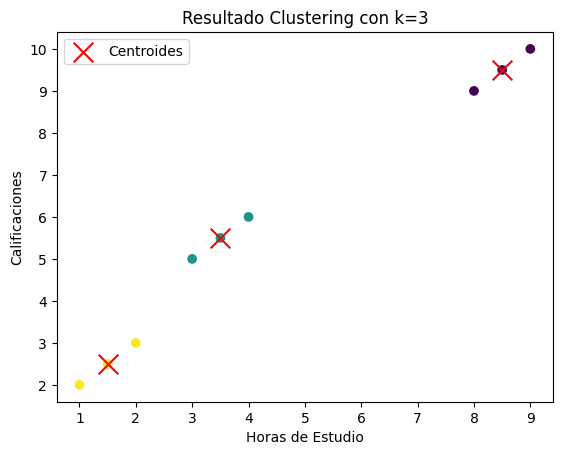

In [10]:
# Visualización final
plt.scatter(df["Horas_estudio"], df["Calificaciones"], c=df['Cluster'], cmap='viridis')
plt.scatter(centroides[:, 0], centroides[:, 1], marker='x', color='red', s=200, label='Centroides')
plt.xlabel("Horas de Estudio")
plt.ylabel("Calificaciones")
plt.title(f"Resultado Clustering con k={k_optimo}")
plt.legend()
plt.show()